# Reto: Predicción de cancelaciones de hotel.

Los datos de cancelaciones de reservaciones en un hotel, tiene un fuerte desbalance. Hay mucho menos cancelaciones, que cancelaciones, lo cual tiene sentido, de otra manera mejor cerramos el hotel =). El desbalance es medianamente grande que sí no se aplican medidas para tratar este problema, no importa que tan bueno sea tu algoritmo muy probablemente no va a lograr detectar los casos en los que sí se van a cancelar las reservaciones, que es la clase que nos interesa. Nos interesa porque como hotel, lo que quisieramos es evitar tener cuartos vacios a lo largo del año, es preferible invertir un poco más de dinero para influir en los clientes que quieren cancelar para que no cancelen. Puedes implementar alguna camapaña para promover o emocionar a los clientes para que vengan, pero primero es necesario identificar de manera sistemática quiénes serán. No quieres enviarle a todo mundo una camapaña porque te cuesta dinero (supón que les regalas una noche extra o una cena, etc).

En este cuaderno, les muestro la manera en la que pueden aplicar downsampling, que consiste en igualar el número de observaciones de la clase mayoritaria al número de observaciones de la clase minoritaria. Para hacer esto hay que sacar muestras aleatorias sin reemplazo. Con esto vamos a lograr un conjunto balanceado en el que nuestros algorítmos se desempeñaran mejor.

## Setup del ambiente de trabajo en Google Colab.

* Para que puedas reproducir los códigos de la clase es importante que fijes las librerías de Python en tu cuaderno de Colab a aquellas que se utilizaron en clase.
* Recuerda que el software evoluciona todo el tiempo y que si no fijamos las librerías de nuestro proyecto corremos el riesgo de que se rompa el código en el futuro.
* El Google Colab instala por lo general las últimas versiones de las librerías.

In [ ]:
# Instalar última versión de yellowbrick y sklearn
#!pip install numpy==1.20.3 pandas==1.2.4 yellowbrick==1.3.post1 scikit-learn==0.24.2 ydata-profiling

In [ ]:
!pip install ydata-profiling

* Una vez que ejecutes este código reinicia el Kernel de la sesión.
* Comenta este código y comienza a ejecutar el código.

In [ ]:
# Liberías estandar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Funciones de Scikit-Learn
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    RandomizedSearchCV,
    train_test_split
)

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

# Funciones de Yellow Brick
from yellowbrick.target import ClassBalance
from yellowbrick.model_selection import (ValidationCurve, FeatureImportances)
from yellowbrick.classifier.threshold import DiscriminationThreshold
from yellowbrick.classifier import (
    ConfusionMatrix,
    ClassPredictionError,
    ClassificationReport,
    PrecisionRecallCurve,
    ROCAUC,
    ClassPredictionError
)

# Importar xgboost
import xgboost as xgb

# Configurar visualizaciones
sns.set_theme(style="whitegrid")
pd.options.display.max_rows = 999
pd.options.display.max_columns = 999

%matplotlib inline

* Si configuraste bien el ambiente de trabajo de tu Google Colab no deberías de tener problema para importar las librerías del curso y ejecutar el código visto en clase.

## Cargar los datos

Cargamos los datos. Nuestra variable a predecir es `is_canceled`. (1) es cancelada y (0) no cancelada.

In [ ]:
# https://github.com/rfordatascience/tidytuesday/tree/master/data/2020/2020-02-11
tbl_data = (
    # Read data from the internet
    pd.read_csv("https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-02-11/hotels.csv")
)

In [ ]:
tbl_data

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,0.0,0,BB,BEL,Offline TA/TO,TA/TO,0,0,0,A,A,0,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,0.0,0,BB,FRA,Online TA,TA/TO,0,0,0,E,E,0,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,0.0,0,BB,DEU,Online TA,TA/TO,0,0,0,D,D,0,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07


In [ ]:
pd.crosstab(tbl_data.is_canceled, tbl_data.reservation_status)

reservation_status,Canceled,Check-Out,No-Show
is_canceled,,,
0,0,75166,0
1,43017,0,1207


## Análisis Exploratorio de Datos (EDA)

* Aqui hay un análisis exploratorio de datos para entender los datos.
* Revísalo cuidadosamente para entender que tienen los datos.

Este reporte se construye con una librería que se llama `pandas_profiling`. Automatiza muchas gráficas y tablas resumen que se usan en los EDA. es útil como herramienta, pero en la práctica no es suficiente, hay que seguir explorando los datos con mayor detalle. Para este proyecto es suficiente y un buen punto de partida. Si quieres conocer más puedes checar la [documentación](https://pypi.org/project/pandas-profiling/).

In [ ]:
# En Google Colab ejecuta esta celda una sola vez. Después de instalar y reiniciar
# la sesión puedes comentar esta linea.
from ydata_profiling import ProfileReport
profile=ProfileReport(tbl_data, title="Pandas Profiling Report")
profile

Output hidden; open in https://colab.research.google.com to view.

## Checar el desbalance en los datos.

In [ ]:
(tbl_data
     .groupby(['is_canceled'])
     .size()
     .reset_index(name = 'n_reservaciones')
     .assign(pct = lambda df_: df_.n_reservaciones / df_.n_reservaciones.sum() * 100)
     .round(1)
)

,is_canceled,n_reservaciones,pct
0,0,75166,63.0
1,1,44224,37.0


[]

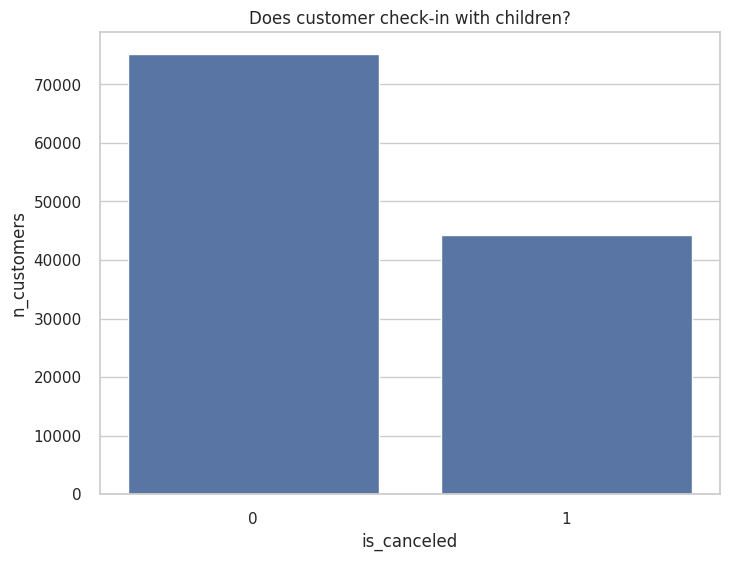

In [ ]:
fig, ax = plt.subplots(figsize = (8, 6))
sns.barplot(
    data = (tbl_data
            .groupby(['is_canceled'])
            .size()
            .reset_index(name = 'n_customers')),
    x = 'is_canceled',
    y = 'n_customers'
)
plt.title("Does customer check-in with children?")
plt.plot()

## Corregir desbalance con downsampling

* Construimos una función para hacer el downsampling, lo único que necesitas es pandas.
* Probablemente, no conozcas lo que hace `query`, es una función que encadenas a un pandas dataframe y te permite filtrar las filas (checa la [documentación](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.query.html)).
* La función `sample` te permite encadenarla a un pandas dataframe y sacar filas de manera aleatoria (checa la [documentación](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sample.html)).

In [ ]:
def fun_downsample(tbl):
    '''
    Función para hacer downsampling
    tbl: Son los datos originales en forma de dataframe.
    '''
    # Filtramos la clase mayoritaria y sacamos de manera aleatoria N observaciones.
    # N es igual al número de observaciones en la clase minoritaria.
    # Observa que fijo una semilla en el random_state para garantizar reproducibilidad.
    tbl_reservations_not_cancelled = (
        tbl
            .query('is_canceled == 0')
            .sample(
                n = tbl.groupby(['is_canceled']).size()[1],
                random_state=42)
    )
    # Filtramos la clase minoritaria.
    tbl_reservations_cancelled = tbl.query('is_canceled == 1')

    return pd.concat([
        tbl_reservations_not_cancelled,
        tbl_reservations_cancelled
    ])

tbl_downsampled_data = fun_downsample(tbl_data)

* Observa como igualamos las proporciones de las clases a 50:50
* Desde luego que perdemos mucha información, sin embargo, el costo no es superior al beneficio.
* El beneficio será que nuestro algorítmo será capaz de atrapar más verdaderos positivos sin debalance.
* Puede haber casos en los que esto no funcione y tengamos que aplicar otra distribución, pero por ahora lo dejamos así.

In [ ]:
(tbl_downsampled_data
     .groupby(['is_canceled'])
     .size()
     .reset_index(name = 'n_reservaciones')
     .assign(pct = lambda df_: df_.n_reservaciones / df_.n_reservaciones.sum() * 100)
     .round(1)
)

,is_canceled,n_reservaciones,pct
0,0,44224,50.0
1,1,44224,50.0


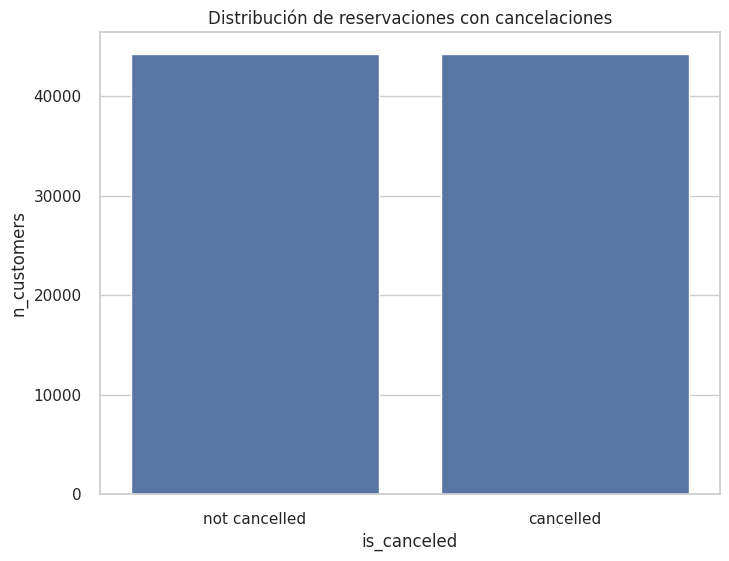

In [ ]:
fig, ax = plt.subplots(figsize = (8, 6))
sns.barplot(
    data = (tbl_downsampled_data
            .groupby(['is_canceled'])
            .size()
            .reset_index(name = 'n_customers')
            .assign(is_canceled = lambda df_: df_.is_canceled.replace({0: 'not cancelled', 1: 'cancelled'}))),
    x = 'is_canceled',
    y = 'n_customers'
)
plt.title("Distribución de reservaciones con cancelaciones")
plt.show()

## Construimos los conjuntos de entrenamiento

* Observa que para construir los conjuntos de entrenamiento y prueba usamos `tbl_downsampled_data` los nuevos datos y no `tbl_data` que son los datos originales.

In [ ]:
from sklearn.model_selection import train_test_split

y = tbl_downsampled_data.is_canceled
X = tbl_downsampled_data.drop(columns = 'is_canceled')

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
print(f'X_train shape: {X_train.shape}')
print(f'y_train shape: {y_train.shape}')

X_train shape: (70758, 31)
y_train shape: (70758,)


In [ ]:
print(f'X_test shape: {X_test.shape}')
print(f'y_test shape: {y_test.shape}')

X_test shape: (17690, 31)
y_test shape: (17690,)


## A partir de aqui puedes seguir el flujo de ML que hemos visto en clase ...

* Dado que lo que queremos es resolver un problema de clasificar cada reservación como cancelada y no cancelada, lo que queremos construir es un modelo de aprendizaje supervisado para clasificación.

* Aqui tienes que ejecutar el código visto en la clase asíncrona del Profundiza.

### Paso 1. Selecciona y extrae las características de tu modelo.

* Recuerda que tienes que aplicar tus transfomaciones y selección de variables tanto al conjunto de entrenamiento como al conjunto de prueba. Tu elige como hacerlo.

* Con lo único que tienes que tener cuidado es con las variables categóricas que tienen muchas clases, porque puede ser que al momento de convertirlas en dummies no tengas el mismo número de columnas o tengas columnas diferentes. TIP: No uses `pd.get_dummies()` utiliza `OneHotEncoder` de `scikit-learn`. Puedes ir a la grabación de la segunda clase síncrona para ver la discusión que tuvimos en clase.

* TIP: Toma el código que vimos en la segunda clase, que ya implementa el OneHotEncoder y modifica, lo que tengas qeu modificar.

* TIP: No selecciones la variable de `reservation_status`, porque si observas en el EDA, es lo mismo que la variable `is_cancelled`. No entrenas un modelo pasándole la respuesta, obvio va a sacar score perfectp. Por eso es muy importante que revises el análisis exploratorio de los datos y no metas todo a la licuadora.

In [ ]:
X_test

,hotel,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
29618,Resort Hotel,93,2016,October,44,27,2,4,2,0.0,0,HB,AUT,Online TA,TA/TO,0,0,0,E,E,2,No Deposit,240.0,NaN,0,Transient,102.93,1,1,Check-Out,2016-11-02
44777,City Hotel,51,2015,October,42,11,1,0,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,8.0,NaN,0,Transient,94.50,0,1,Check-Out,2015-10-12
19188,Resort Hotel,92,2016,February,9,26,1,2,2,0.0,0,Undefined,PRT,Groups,TA/TO,0,1,0,A,A,0,Non Refund,134.0,NaN,0,Transient,79.00,0,0,Canceled,2015-12-10
11604,Resort Hotel,226,2017,May,20,20,2,5,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,D,D,0,No Deposit,240.0,NaN,0,Transient,76.03,0,1,Canceled,2016-10-08
77126,City Hotel,5,2015,September,37,6,2,0,1,0.0,0,HB,PRT,Direct,Direct,0,0,0,D,G,1,No Deposit,14.0,NaN,0,Transient,171.00,1,0,Check-Out,2015-09-08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12819,Resort Hotel,7,2017,July,29,18,0,1,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,G,G,0,No Deposit,250.0,NaN,0,Transient,255.00,0,0,Canceled,2017-07-12
79502,City Hotel,105,2016,September,40,28,0,1,1,0.0,0,BB,PRT,Corporate,Corporate,1,1,11,A,A,1,No Deposit,NaN,40.0,0,Transient,65.00,0,0,Check-Out,2016-09-29
107543,City Hotel,0,2017,March,11,15,0,0,0,0.0,0,SC,PRT,Offline TA/TO,TA/TO,1,0,0,A,K,0,No Deposit,132.0,NaN,0,Transient,0.00,0,0,Check-Out,2017-03-15
98910,City Hotel,107,2016,October,41,3,1,3,2,0.0,0,BB,DEU,Offline TA/TO,TA/TO,0,0,0,A,A,0,No Deposit,85.0,NaN,0,Transient,80.75,0,0,Check-Out,2016-10-07


In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
import pandas as pd # Asegurarse de importar pandas
import numpy as np  # Asegurarse de importar numpy

variable_selection_numeric = ['arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'previous_cancellations', 'previous_bookings_not_canceled']
variable_selection_categoric = ['hotel', 'arrival_date_month', 'meal', 'market_segment', 'distribution_channel']               # <--- Selecciona las variable categóricas

def prep_for_ml(tbl_train, tbl_test):
    '''Clean X_train and X_test
        1) Select continuous and categorical variables.
        2) Convert categorical variables to one hot encoding
        3) Concatenate clean dataframes
    '''
    # Continuous variables
    tbl_num_train = tbl_train.loc[:, variable_selection_numeric]
    tbl_num_test = tbl_test.loc[:, variable_selection_numeric]

    scaler = StandardScaler()
    scaler.fit(tbl_num_train)
    X_train_standarized = scaler.transform(tbl_num_train)
    X_test_standarized = scaler.transform(tbl_num_test)

    # Convert standardized numpy arrays back to pandas DataFrames
    X_train_standarized_df = pd.DataFrame(X_train_standarized, columns=variable_selection_numeric)
    X_test_standarized_df = pd.DataFrame(X_test_standarized, columns=variable_selection_numeric)


    #############################################################

    # Categorical variables
    tbl_cat_train = tbl_train.loc[:, variable_selection_categoric]
    tbl_cat_test = tbl_test.loc[:, variable_selection_categoric]

    ohe = OneHotEncoder(drop = 'first', sparse_output = False)
    ohe.fit(tbl_cat_train)
    col_names = ohe.get_feature_names_out()

    tbl_ohe_cat_train = pd.DataFrame(
        ohe.transform( tbl_cat_train )
    )

    tbl_ohe_cat_test = pd.DataFrame(
        ohe.transform( tbl_cat_test )
    )
    # Add new column names
    tbl_ohe_cat_train.columns = col_names
    tbl_ohe_cat_test.columns = col_names

    #############################################################

    # Join transformed continuous + categorical variables
    # Use the converted DataFrames for concatenation
    tbl_train_clean = pd.concat([X_train_standarized_df.reset_index(drop = True), tbl_ohe_cat_train.reset_index(drop = True)], axis = 1)
    tbl_test_clean = pd.concat([X_test_standarized_df.reset_index(drop = True), tbl_ohe_cat_test.reset_index(drop = True)], axis = 1)

    return (tbl_train_clean, tbl_test_clean)

X_train_clean, X_test_clean = prep_for_ml(X_train, X_test)

* Estas líneas nos sirven para validar que las columnas de los tres conjuntos de datos después de aplicar el preprocesamiento están correctas.
* Si genera error es porque no tienes las mismas columnas, puedes investigar por qué?
* **HINT: Los errores en el código son comúnes, y están diseñados para decirte que es lo que está fallando. Cómo cientifico de datos, pasas una parte importante debuggeando código. Si tienes un error que no entiendes, lo copias y pegas en Google y puedes investigar que dice la comunidad y cómo se resuelve. O puedes preguntar.**

In [ ]:
assert X_train_clean.columns.tolist() == X_test_clean.columns.tolist()

### Paso 2: Construye un modelo base

* Construye un modelo sencillo. Recuerda que estas viendo problemas de clasificación, por lo que tienes que escoger la implementación correcta. Por ejemplo:
    - [LogisticRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html#sklearn.linear_model.LogisticRegression)
    - [Support Vector Classification (SVC¶)](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#sklearn.svm.SVC)
    - [K nearest neighbors (KNeighborsClassifier¶)](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html#sklearn.neighbors.KNeighborsClassifier)
    - [Decision Trees (DecisionTreeClassifier)](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html#sklearn.tree.DecisionTreeClassifier)
    - [Random Forest (RandomForestClassifier)](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html#sklearn.ensemble.RandomForestClassifier)
    - [Xgboost (XGBClassifier)](https://xgboost.readthedocs.io/en/stable/python/python_api.html#xgboost.XGBClassifier)
    
* Entrena el modelo y calcula la métricas de error para un problema de clasificación: precision, recall, f1 score, y la matriz de confusión. Utiliza las funciones de yellowbrick que vimos en clase.

* Analiza los resultados, que implica para el hotel. ¿Qué dicen los Falsos Negativos, Falsos Positivos? ¿Qué implica una precision o recall de X en la operación del hotel utilizando tu modelo?

In [ ]:
from sklearn.linear_model import LogisticRegression

# Fit the model on the preprocessed training data
clf = LogisticRegression(random_state=0).fit(X_train_clean, y_train)

# Use the preprocessed test data for prediction and scoring
# This ensures the feature names match those used during fitting
clf.predict(X_test_clean)
clf.predict_proba(X_test_clean)
clf.score(X_test_clean, y_test) # Use y_test for scoring against the test set

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.6422837761447145

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


0.6422837761447145

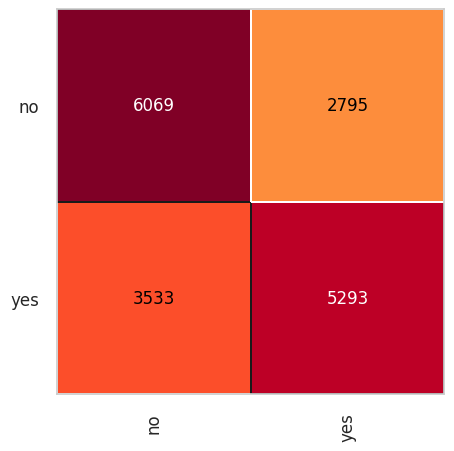

In [ ]:
from yellowbrick.classifier import ConfusionMatrix
fig, ax = plt.subplots(figsize = (5,5))
# Creamos la matrix de confusión
cm = ConfusionMatrix(
    clf, 				# Pasar el estimador del mejor modelo que
    							# se obtiene de la validación cruzada.
    classes=['no', 'yes']		# Indicar las etiquetas de las clases.
    							# Cuidado con el orden de los nombres.
)
# Ajustamos la visualización a los datos de entrenamiento
cm.fit(X_train_clean, y_train) # Use X_train_clean as X_train was not preprocessed
# Evaluamos los errores en la predicción utilizando los datos de validación.
cm.score(X_test_clean, y_test) # Use X_test_clean and y_test for scoring

### Paso 3: Busca los mejores hiperparámetros de tu modelo

* Para esto puedes utilizar el `GridSearch` o el `RandomSearch`, tu elige la implementación que quiras, solo ten cuidado con los parámetros que les tienes que pasar porque hay sutilezas. Tienes los códigos de las clases y la documentación como referencia.

* Escoge los hiperparámetros correctos. TIP: Puedes tomar como referencia la tabla del libro que les pasé por correo de Canvas. Puedes ajustar los rangos de los hiperparámetros según los resultados que observes.

* Calcula los las mismas métricas que sacaste en el modelo base, ¿mejoraron los resultados?

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
import xgboost as xgb
params = {
    'n_estimators':[150],
    'learning_rate':[.01],
    'max_depth':[10],
    'subsample':[0.75],
    'colsample_bytree':[0.75],
    'colsample_bylevel':[0.75],
    'reg_lambda':[0.01]
}
clf_xgb = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
grid_search = RandomizedSearchCV(
	clf_xgb,					# Especificar el modelo (estimador)
	params,						# Especificar los parámetros de la malla
	scoring = 'roc_auc', 		# Especificar la métrica de evaluación
	cv = 10,					# Especificar los k-cortes de la validación cruzada
	n_iter=2,					# Especificar número de modelos a explorar aleatoriamente
    return_train_score=True,# Agregar el error de entrenamiento
	n_jobs=-1					# Especificar el número de CPUs para paralelizar el trabajo
    							# -1= todos los disponibles
)

### Paso 4: Prueba con otro modelo y ajusta sus hiperparámetros como en el paso 3.

In [ ]:
# Random Forest
# Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate

rfcInicial_model = RandomForestClassifier(n_estimators = 10, max_depth = 3)

# Use the cleaned training data (X_train_clean) for cross_validate
scores = pd.DataFrame(cross_validate(rfcInicial_model, X_train_clean, y_train, cv = 10, return_train_score = True))

print("Score promedio de entrenamiento: ", scores['train_score'].mean())
print("Score promedio de validación: ", scores['test_score'].mean())
scores

Score promedio de entrenamiento:  0.6179780226927928
Score promedio de validación:  0.6178098864024514


,fit_time,score_time,test_score,train_score
0,0.166209,0.006788,0.597937,0.605540
1,0.139558,0.007433,0.622809,0.620646
2,0.145978,0.006517,0.627756,0.627509
3,0.144574,0.006613,0.638496,0.628482
4,0.144906,0.006646,0.615602,0.612889
5,0.147476,0.008960,0.610514,0.612889
6,0.134886,0.006124,0.605568,0.611868
7,0.141403,0.006468,0.631854,0.624368
8,0.131359,0.005921,0.613852,0.616271
9,0.159163,0.007066,0.613710,0.619318


In [ ]:
from sklearn.model_selection import GridSearchCV


parameters = {'max_depth': [2, 3, 5, 7],
              'max_features': ['sqrt', 'log2', None],
              'n_estimators': [10, 30, 60, 100]}

# It is recommended to use the cleaned training data (X_train_clean) for hyperparameter tuning as well,
# to ensure consistency with the model training after the search.
rfc_grid = GridSearchCV(RandomForestClassifier(random_state = 1), param_grid = parameters,
                        return_train_score=True)
rfc_grid.fit(X_train_clean, y_train) # Use X_train_clean here

print("Mejores hiperparámetros\n",rfc_grid.best_params_)

Mejores hiperparámetros
 {'max_depth': 7, 'max_features': 'sqrt', 'n_estimators': 100}


In [ ]:
rfc_model = rfc_grid.best_estimator_
rfc_model.score(X_test_clean, y_test)

0.666704352741662

              precision    recall  f1-score   support

           0       0.67      0.67      0.67      8864
           1       0.67      0.66      0.67      8826

    accuracy                           0.67     17690
   macro avg       0.67      0.67      0.67     17690
weighted avg       0.67      0.67      0.67     17690



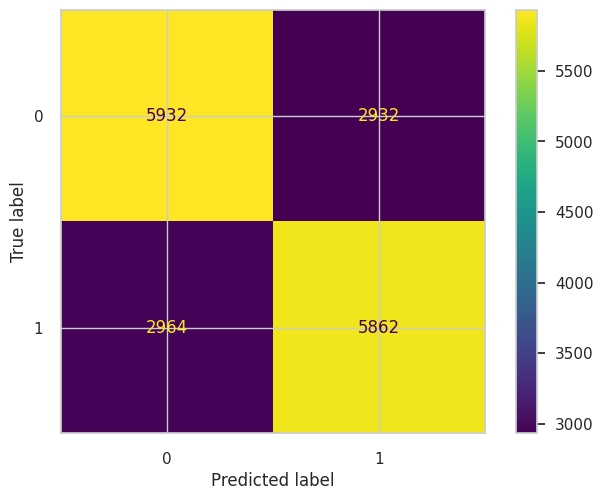

In [ ]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay # Import ConfusionMatrixDisplay and classification_report

# Use the cleaned test data (X_test_clean) for the Confusion Matrix display
ConfusionMatrixDisplay.from_estimator(rfc_model, X_test_clean, y_test)

# Use the cleaned test data (X_test_clean) for the classification report
print(classification_report(y_test, rfc_model.predict(X_test_clean)))

In [ ]:
# Máquina de vectores de soporte
from sklearn.svm import SVC
from sklearn.model_selection import cross_validate # Ensure cross_validate is also imported if not already in this cell

svmc_model = SVC(C = 0.01, kernel = "poly")

# Note: It is recommended to use the cleaned training data (X_train_clean)
# for cross-validation to match the preprocessing applied to the data
# you will use for training your final model.
scores = pd.DataFrame(cross_validate(svmc_model, X_train_clean, y_train, cv = 10, return_train_score = True))

print("Score promedio de entrenamiento: ", scores['train_score'].mean())
print("Score promedio de validación: ", scores['test_score'].mean())
scores

Score promedio de entrenamiento:  0.6532013646835871
Score promedio de validación:  0.6511065663657774


,fit_time,score_time,test_score,train_score
0,337.184685,17.368553,0.642736,0.650906
1,328.915942,16.713688,0.650650,0.653466
2,330.283442,16.460765,0.657858,0.653481
3,327.038709,17.470262,0.653618,0.653026
4,330.876634,16.633705,0.654183,0.653434
5,350.834672,17.323538,0.653335,0.652838
6,330.952813,17.001380,0.649378,0.654565
7,328.206068,17.597341,0.648672,0.653356
8,339.832748,16.675379,0.650318,0.652435
9,329.040325,16.921081,0.650318,0.654507


In [ ]:
from sklearn.svm import SVC
parameters = {'C': [0.01, 0.1, 1, 10, 50],
              'kernel': ['linear', 'poly', 'rbf', 'sigmoid']}
svmc_grid = GridSearchCV(SVC(random_state = 1), param_grid = parameters,
                         return_train_score = True)
svmc_grid.fit(X_train_clean, y_train)
print("Mejores hiperparámetros\n",svmc_grid.best_params_)

### Paso 5: Selecciona el mejor modelo y calcula las predicciones

* Utiliza el mejor modelo para calcular las predicciones utiliznado el conjunto de prueba.
    - Predice la clase
    - Predice la probabilidad de cancelación
* Grafica la curva ROC del mejor modelo.
* Reporta la precision y el recall.
* Interpreta los resultados en función de lo que estos implican pra el modelo si utilizan tu modelo.

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 1 is smaller than n_iter=2. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [01:29:32] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


<Figure size 800x550 with 0 Axes>

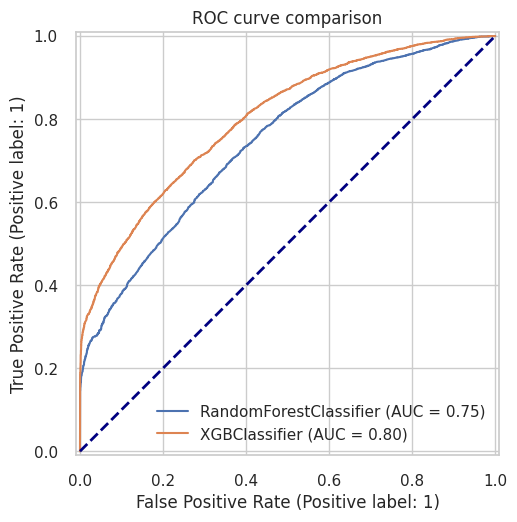

In [ ]:
# Curva ROC
from sklearn.metrics import RocCurveDisplay
import xgboost as xgb
import matplotlib.pyplot as plt # Import matplotlib.pyplot

plt.figure()
lw = 2
disp = RocCurveDisplay.from_estimator(rfc_model, X_test_clean, y_test)

# Fit the RandomizedSearchCV object
grid_search.fit(X_train_clean, y_train)

# Get the best estimator from the fitted search
best_xgb_model = grid_search.best_estimator_

# Use the best estimator to plot the ROC curve
RocCurveDisplay.from_estimator(best_xgb_model, X_test_clean, y_test, ax=disp.ax_)

plt.plot([0, 1], [0, 1], color = "navy", lw=lw, linestyle = "--")
plt.title("ROC curve comparison")
plt.legend(loc = "lower right")
plt.show()


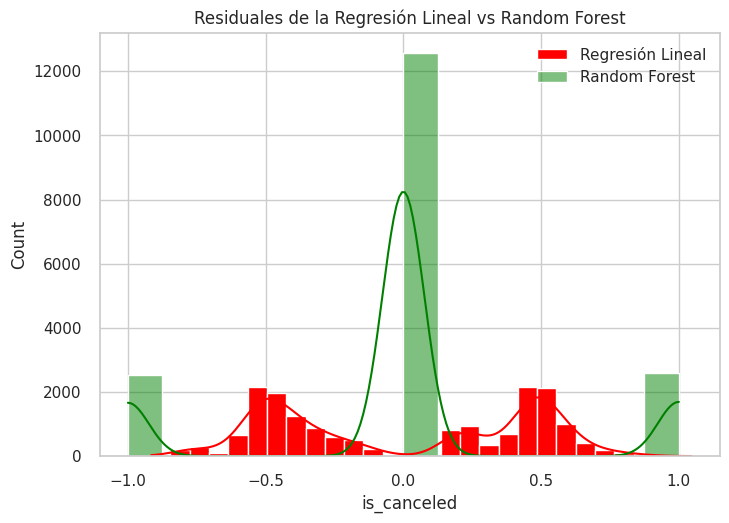

In [ ]:
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns

lr = LinearRegression()
lr.fit(X_train_clean, y_train)

fig, ax = plt.subplots()
# Historgrama de regresión lineal
sns.histplot(
    y_test - lr.predict(X_test_clean),
    color = 'red',
    alpha = 1, label = 'Regresión Lineal',
    kde = True
)
# Histograma de random forest
sns.histplot(
    y_test - grid_search.best_estimator_.predict(X_test_clean), # Changed random_search to grid_search
    color = 'green',
    alpha = 0.5,
    label = 'Random Forest',
    kde = True
)
plt.title("Residuales de la Regresión Lineal vs Random Forest")
plt.legend()
plt.show()

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


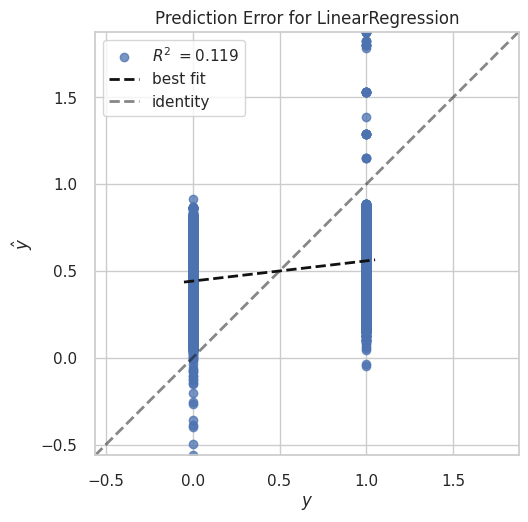

In [ ]:
from yellowbrick.regressor import PredictionError
visualizer = PredictionError(lr)
visualizer.fit(X_train_clean, y_train)
visualizer.score(X_test_clean, y_test)
visualizer.show();

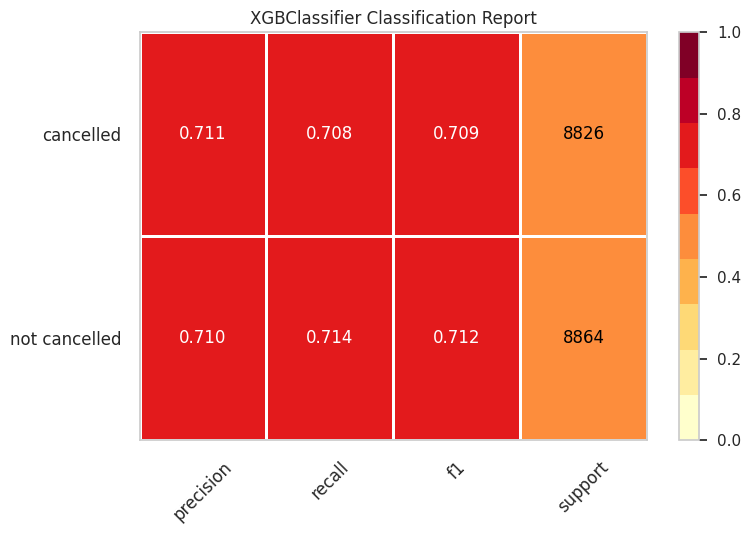

<Axes: title={'center': 'XGBClassifier Classification Report'}>

In [ ]:
from yellowbrick.classifier import ClassificationReport
import matplotlib.pyplot as plt

best_xgb_model = grid_search.best_estimator_

visualizer = ClassificationReport(best_xgb_model, classes=['not cancelled', 'cancelled'], support=True)

visualizer.fit(X_train_clean, y_train)
visualizer.score(X_test_clean, y_test)

visualizer.show()


### Paso 5: Genera un CSV con tus predicciones para compartir con el hotel, utilizando tu mejor modelo entrenado con los datos de prueba.

* Reporta en tu CSV la predicción de la clase y la predicción de la probabilidad de cancelación.

In [ ]:
probability_of_cancellation = rfc_model.predict_proba(X_test_clean)[:, 1]
cancellation_classification = rfc_model.predict(X_test_clean)

output_df = pd.DataFrame({
    'id': X_test_clean.reset_index(drop=True).index,
    'probability_of_cancellation': probability_of_cancellation * 100,
    'cancellation_classification': cancellation_classification
})

output_df = output_df[['id', 'probability_of_cancellation', 'cancellation_classification']]

output_df.to_csv('cancellation_predictions.csv', index=False)

print("CSV file 'cancellation_predictions.csv' generated successfully.")
print(output_df.head())

CSV file 'cancellation_predictions.csv' generated successfully.
   id  probability_of_cancellation  cancellation_classification
0   0                    48.551674                            0
1   1                    45.804235                            0
2   2                    88.839581                            1
3   3                    51.036755                            1
4   4                    26.737536                            0
